In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectFromModel, RFE, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [8]:
# Step 1: Data loading and initial exploration
print("="*80)
print("Step 1: Data Loading and Initial Exploration")
print("="*80)

# Read Excel file
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ Data loaded successfully, shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Read failed: {e}")

# Basic information
print(f"\nBasic dataset information:")
print(f"  • Number of rows: {len(df)}")
print(f"  • Number of columns: {len(df.columns)}")
print(f"  • Column names: {list(df.columns)[:5]}... (total {len(df.columns)} columns)")

# Define target and feature columns
first_col = df.columns[0]  # Assume the first column is ID/time
target_col = df.columns[-1]  # The last column is the target
feature_cols = df.columns[1:-1]  # Middle columns are features

print(f"\nColumn roles:")
print(f"  • ID/index column: {first_col}")
print(f"  • Target column: {target_col}")
print(f"  • Number of feature columns: {len(feature_cols)}")

# Extract X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\nTarget variable statistics:")
print(f"  • Data type: {y.dtype}")
print(f"  • Non-null values: {y.notna().sum()}/{len(y)}")
print(f"  • Min: {y.min():.6f}")
print(f"  • Max: {y.max():.6f}")
print(f"  • Mean: {y.mean():.6f}")
print(f"  • Std: {y.std():.6f}")

Step 1: Data Loading and Initial Exploration
✓ Data loaded successfully, shape: (7200, 59)

Basic dataset information:
  • Number of rows: 7200
  • Number of columns: 59
  • Column names: ['Date', 'PI-2', 'TI-2', 'FI-2', 'PI-3']... (total 59 columns)

Column roles:
  • ID/index column: Date
  • Target column: CO2 capacity
  • Number of feature columns: 57

Target variable statistics:
  • Data type: float64
  • Non-null values: 7200/7200
  • Min: 0.582062
  • Max: 0.948009
  • Mean: 0.864631
  • Std: 0.045872


In [9]:
# Step 2: Data cleaning and conversion to numeric types
print("\n" + "="*80)
print("Step 2: Data Cleaning and Numeric Conversion")
print("="*80)

# Convert to numeric type (non-numeric values become NaN)
X_numeric = X.apply(pd.to_numeric, errors='coerce')
y_numeric = pd.to_numeric(y, errors='coerce')

# Missing value statistics
print(f"\n[Missing Value Statistics]")
X_na_count = X_numeric.isna().sum().sum()
y_na_count = y_numeric.isna().sum()
print(f"  • Missing values in X: {X_na_count}")
print(f"  • Missing values in y: {y_na_count}")

# Key decision: whether to drop rows with missing values
# Current choice: keep all original samples (fill NaN values) to stay consistent with previous calculations
# This preserves sample counts used in correlation analysis
X_numeric = X_numeric.fillna(X_numeric.median())
y_numeric = y_numeric.fillna(y_numeric.median())

print(f"\n[Cleaning Method]")
print(f"  • Missing-value handling: median imputation (all original samples kept)")
print(f"  • Number of samples: {len(X_numeric)} (no rows removed)")
print(f"  • Number of features: {X_numeric.shape[1]} (total {len(X_numeric.columns)} columns)")
print(f"  • Feature names: {list(X_numeric.columns)[:10]}... ")

print(f"\nNote:")
print(f"  Benefits of keeping original samples:")
print(f"    • Correlation results remain consistent with previous calculations")
print(f"    • No information loss from dropping rows")
print(f"    • All data points remain available for time-series modeling")



Step 2: Data Cleaning and Numeric Conversion

[Missing Value Statistics]
  • Missing values in X: 0
  • Missing values in y: 0

[Cleaning Method]
  • Missing-value handling: median imputation (all original samples kept)
  • Number of samples: 7200 (no rows removed)
  • Number of features: 57 (total 57 columns)
  • Feature names: ['PI-2', 'TI-2', 'FI-2', 'PI-3', 'TI-3', 'O2-3', 'TI-32', 'TI-33', 'TI-34', 'TI-35']... 

Note:
  Benefits of keeping original samples:
    • Correlation results remain consistent with previous calculations
    • No information loss from dropping rows
    • All data points remain available for time-series modeling



Step 4: Spearman and Mutual Information Correlation Assessment

Evaluation Methods:
  1. Spearman rank correlation: Measures monotonic relationships, robust to outliers
  2. Mutual Information (MI): Captures nonlinear relationship strength, based on information theory


[Top 15 Features (sorted by Spearman)]
Feature  Spearman_rho  MutualInfo
  TI-34      0.782138    1.162118
  TI-33      0.637963    1.060517
  TI-35      0.542904    0.754401
  FI-30      0.489813    0.578367
  FI-38      0.459527    0.418344
   TI-4      0.454329    0.914921
  TI-19      0.449894    0.836789
  TI-12      0.434928    0.848616
  TI-22      0.433888    0.827448
   PI-2      0.430400    0.292156
  TI-24      0.404121    1.002042
  FI-23      0.396202    0.958113
  FI-36      0.393140    0.261021
   PI-1      0.391168    0.386529
 TI-212      0.346454    0.671150

[Spearman Correlation Statistics]
  • Strong correlation (|rho| > 0.7): 1
  • Moderate correlation (0.5 < |rho| < 0.7): 2
  • Weak correlation (

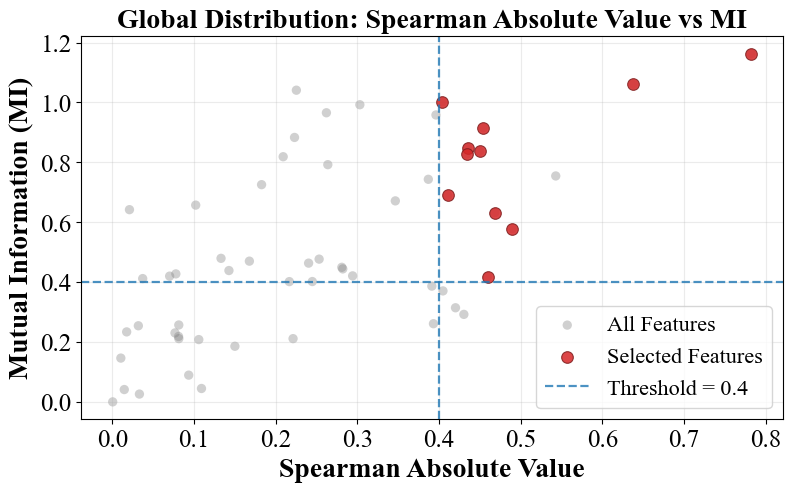

✓ Saved chart as 'spearman_mi_correlation_comparison.png'

✓ Step 4 Completed: Spearman and Mutual Information Correlation Assessment


In [10]:
# Step 4: Spearman and Mutual Information Correlation Assessment
print("\n" + "="*80)
print("Step 4: Spearman and Mutual Information Correlation Assessment")
print("="*80)

print("""
Evaluation Methods:
  1. Spearman rank correlation: Measures monotonic relationships, robust to outliers
  2. Mutual Information (MI): Captures nonlinear relationship strength, based on information theory
""")

from sklearn.feature_selection import mutual_info_regression

# Compute correlations
corr_results = []

for col in X_numeric.columns:
    # 1. Spearman rank correlation coefficient
    spearman_r, spearman_p = spearmanr(X_numeric[col], y_numeric)
     
    # 2. Mutual Information (captures nonlinear relationships)
    try:
        mi_score = mutual_info_regression(
            X_numeric[[col]], y_numeric, random_state=42
        )[0]
    except:
        mi_score = np.nan
    
    corr_results.append({
        'Feature': col,
        'Spearman_rho': spearman_r,
        'Spearman_p': spearman_p,
        'MutualInfo': mi_score,
        'abs_Spearman': abs(spearman_r)
    })

# Create results DataFrame (sorted by Spearman)
corr_df = pd.DataFrame(corr_results).sort_values('Spearman_rho', ascending=False)

# Print Top 15 Features (sorted by Spearman)
print("\n[Top 15 Features (sorted by Spearman)]")
print(corr_df[['Feature', 'Spearman_rho', 'MutualInfo']].head(15).to_string(index=False))

# Statistical analysis
print(f"\n[Spearman Correlation Statistics]")
print(f"  • Strong correlation (|rho| > 0.7): {(corr_df['abs_Spearman'] > 0.7).sum()}")
print(f"  • Moderate correlation (0.5 < |rho| < 0.7): {((corr_df['abs_Spearman'] > 0.5) & (corr_df['abs_Spearman'] <= 0.7)).sum()}")
print(f"  • Weak correlation (0.3 < |rho| < 0.5): {((corr_df['abs_Spearman'] > 0.3) & (corr_df['abs_Spearman'] <= 0.5)).sum()}")
print(f"  • No correlation (|rho| ≤ 0.3): {(corr_df['abs_Spearman'] <= 0.3).sum()}")

print(f"\n[Mutual Information (MI) Statistics]")
print(f"  • Max MI value: {corr_df['MutualInfo'].max():.6f}")
print(f"  • Min MI value: {corr_df['MutualInfo'].min():.6f}")
print(f"  • Mean MI value: {corr_df['MutualInfo'].mean():.6f}")

# Manually specify selected features (excluding 'TI-35')
manual_selected_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 
                             'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']

# Extract these features from corr_df
selected_features = corr_df[corr_df['Feature'].isin(manual_selected_features)].copy()

print(f"\n[Feature Selection Results]")
print(f"  • Manually selected features: {len(selected_features)}")
print(f"  • Excluded feature: TI-35")

if len(selected_features) > 0:
    print(f"\n[Details of Selected Features]")
    print(selected_features[['Feature', 'Spearman_rho', 'MutualInfo']].to_string(index=False))
    print(f"\n  • Selected feature list: {selected_features['Feature'].tolist()}")
else:
    print(f"\n⚠ Warning: No features selected!")

# Save correlation analysis results (all features)
try:
    corr_df.to_csv('spearman_mi_correlation_analysis.csv', index=False, encoding='utf-8-sig')
    print(f"\n✓ Saved complete correlation analysis to 'spearman_mi_correlation_analysis.csv'")
except Exception as e:
    print(f"\n⚠ Failed to save complete results: {e}")

# Save selected features
if len(selected_features) > 0:
    try:
        selected_features.to_csv('selected_features_spearman_mi.csv', index=False, encoding='utf-8-sig')
        print(f"✓ Saved selected features to 'selected_features_spearman_mi.csv'")
    except Exception as e:
        print(f"⚠ Failed to save selected features: {e}")

# Visualize correlation comparison (ONLY keep the 2nd figure: scatter)
print("\n[Generating Scatter Plot: |Spearman| vs MI]")

top_n = 15
top_features = corr_df.head(top_n)  # reserved if you later want top-N highlighting

# Use Times New Roman and 12pt ONLY for this figure
with plt.rc_context({'font.family': 'Times New Roman', 'font.size': 12}):
    fig, ax = plt.subplots(figsize=(8, 5))

    # All features
    ax.scatter(
        corr_df['abs_Spearman'],
        corr_df['MutualInfo'],
        s=45,
        alpha=0.35,
        c='#7A7A7A',
        edgecolors='none',
        label='All Features',
        zorder=1,
    )

    # Highlight selected features
    if len(selected_features) > 0:
        ax.scatter(
            selected_features['abs_Spearman'],
            selected_features['MutualInfo'],
            s=70,
            alpha=0.85,
            c='#D62728',
            edgecolors='#7F1D1D',
            linewidth=0.8,
            label='Selected Features',
            zorder=2,
        )

    # Reference threshold lines
    threshold = 0.4
    ax.axhline(y=threshold, color='#1F77B4', linestyle='--', linewidth=1.6, alpha=0.8, label='Threshold = 0.4')
    ax.axvline(x=threshold, color='#1F77B4', linestyle='--', linewidth=1.6, alpha=0.8)

    ax.set_xlabel('Spearman Absolute Value', fontweight='bold', fontsize=20)
    ax.set_ylabel('Mutual Information (MI)', fontweight='bold', fontsize=20)
    ax.set_title('Global Distribution: Spearman Absolute Value vs MI', fontweight='bold', fontsize=20)

    ax.tick_params(axis='both', labelsize=18)
    ax.xaxis.get_offset_text().set_fontsize(12)
    ax.yaxis.get_offset_text().set_fontsize(12)

    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.legend(frameon=True, fontsize=16)

    plt.tight_layout(pad=0.8)
    plt.savefig('spearman_mi_correlation_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved chart as 'spearman_mi_correlation_comparison.png'")

print("\n" + "="*80)
print("✓ Step 4 Completed: Spearman and Mutual Information Correlation Assessment")
print("="*80)
